In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
file_path = r"/home/lucas/WSL Codes/Iniciação Científica/CAM x CRU/data/atletico_cruzeiro/livechats_atletico_cruzeiro.jsonl"

df = pd.read_json(file_path, lines=True)

df.head()

,author,type,id,timestamp,elapsedTime,datetime,message,amountValue,currency,bgColor,alias,event,video_id,sticker,colors
0,"{'type': '', 'isVerified': False, 'isChatOwner...",textMessage,ChwKGkNQXzI4dE9Vc3ZZQ0ZWTGhPQW9kLTNNRG1R,2022-03-06 18:55:26.727,-8:58,2022-03-06 15:55:26,contra as frangas pode colocar o juniores que ...,0.0,,0,CAMxCRU - 2022-03-07,CAMxCRU - 2022-03-07,VAemMZsM1gY,NaN,NaN
1,"{'type': '', 'isVerified': False, 'isChatOwner...",textMessage,ChwKGkNNSGRxOWVVc3ZZQ0ZjYkR3Z1FkUzk0RTRn,2022-03-06 18:55:33.949,-8:51,2022-03-06 15:55:33,Fábio maior q as frangas,0.0,,0,CAMxCRU - 2022-03-07,CAMxCRU - 2022-03-07,VAemMZsM1gY,NaN,NaN
2,"{'type': '', 'isVerified': False, 'isChatOwner...",textMessage,ChwKGkNOZmNxdDJVc3ZZQ0ZkUUgxZ0FkdzlVQXBB,2022-03-06 18:55:46.515,-8:38,2022-03-06 15:55:46,"3 ANOS NA SÉRIE B, DÁ MUITA DEPRESSÃO. :loudly...",0.0,,0,CAMxCRU - 2022-03-07,CAMxCRU - 2022-03-07,VAemMZsM1gY,NaN,NaN
3,"{'type': '', 'isVerified': False, 'isChatOwner...",textMessage,ChwKGkNNbnF5T0tVc3ZZQ0ZYa2xyUVlkV3FrRF9n,2022-03-06 18:55:57.494,-8:27,2022-03-06 15:55:57,máfia azul vai ganhar :wolf:,0.0,,0,CAMxCRU - 2022-03-07,CAMxCRU - 2022-03-07,VAemMZsM1gY,NaN,NaN
4,"{'type': '', 'isVerified': False, 'isChatOwner...",textMessage,ChwKGkNLcWV6T3FVc3ZZQ0ZlUER3Z1Fkd3RzRXBn,2022-03-06 18:56:14.327,-8:10,2022-03-06 15:56:14,3 qnos na série B e msm assim o maior do estad...,0.0,,0,CAMxCRU - 2022-03-07,CAMxCRU - 2022-03-07,VAemMZsM1gY,NaN,NaN


In [3]:
df["datetime"] = pd.to_datetime(df["datetime"])
df["user"] = df["author"].apply(lambda x: x["name"])
df["event"] = df["event"]

In [4]:
print("Total de mensagens:", len(df))
print("Total de usuários:", df["user"].nunique())
print("Total de partidas:", df["event"].nunique())

Total de mensagens: 303938
Total de usuários: 52753
Total de partidas: 16


In [5]:
msgs_per_user = df.groupby("user").size()

In [ ]:
msgs_per_match = df.groupby("event").size()

event
CAMxCRU - 2022-03-07    41827
CAMxCRU - 2022-04-02    30956
CAMxCRU - 2023-06-04    28235
CAMxCRU - 2025-02-10    26942
CAMxCRU - 2025-09-12    24797
CAMxCRU - 2023-02-14    23686
CAMxCRU - 2023-10-23    22023
CAMxCRU - 2025-08-28    19700
CAMxCRU - 2024-03-31    16602
CAMxCRU - 2024-08-11    12227
CAMxCRU - 2025-10-16    11808
CAMxCRU - 2026-01-26    10003
CAMxCRU - 2026-03-09     9277
CAMxCRU - 2024-02-04     8951
CAMxCRU - 2024-04-08     8604
CAMxCRU - 2024-04-21     8230
dtype: int64

In [11]:
print("\nUsuários:")
print(msgs_per_user.describe())

print("\nPartidas:")
print(msgs_per_match.describe())


Usuários:
count    52753.000000
mean         5.761530
std         19.433385
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max        935.000000
dtype: float64

Partidas:


NameError: name 'msgs_per_match' is not defined

In [7]:
def ccdf_optimized(data):
    values, counts = np.unique(data, return_counts=True)
    
    sorted_idx = np.argsort(values)
    values = values[sorted_idx]
    counts = counts[sorted_idx]
    
    ccdf = np.cumsum(counts[::-1])[::-1] / np.sum(counts)
    
    return values, ccdf

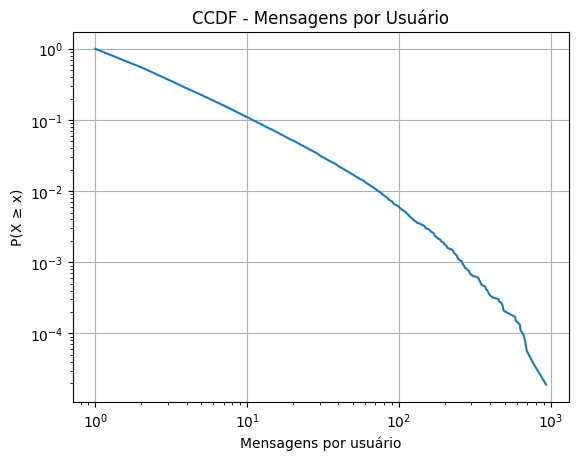

In [8]:
x_u, y_u = ccdf_optimized(msgs_per_user.values)

plt.figure()
plt.loglog(x_u, y_u)
plt.xlabel("Mensagens por usuário")
plt.ylabel("P(X ≥ x)")
plt.title("CCDF - Mensagens por Usuário")
plt.grid(True)
plt.show()

In [9]:
x_m, y_m = ccdf_optimized(msgs_per_match.values)

plt.figure()
plt.loglog(x_m, y_m)
plt.xlabel("Mensagens por partida")
plt.ylabel("P(X ≥ x)")
plt.title("CCDF - Mensagens por Partida")
plt.grid(True)
plt.show()

NameError: name 'msgs_per_match' is not defined

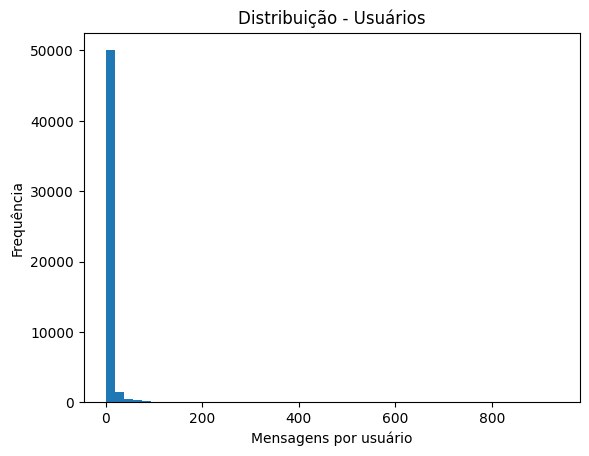

In [12]:
plt.figure()
plt.hist(msgs_per_user, bins=50)
plt.xlabel("Mensagens por usuário")
plt.ylabel("Frequência")
plt.title("Distribuição - Usuários")
plt.show()

In [13]:
plt.figure()
plt.hist(msgs_per_match, bins=20)
plt.xlabel("Mensagens por partida")
plt.ylabel("Frequência")
plt.title("Distribuição - Partidas")
plt.show()

NameError: name 'msgs_per_match' is not defined

<Figure size 640x480 with 0 Axes>

In [14]:
top_users = msgs_per_user.sort_values(ascending=False).head(10)

top_users

user
@vitorb1386                    935
@humbertocarlosmadeira3682     769
@gracasantos1005               696
@roberto-hi3yc                 680
@anapaularochadossantos8473    664
@patriciasouza5905             631
@anapeixoto6537                628
@paulofarias1166               588
@Vanisa-v5f                    584
@mayahrocha                    490
dtype: int64

In [15]:
top_1_percent = int(0.01 * len(msgs_per_user))

top_users = msgs_per_user.sort_values(ascending=False).head(top_1_percent)

print("Proporção de mensagens dos top 1%:")
print(top_users.sum() / msgs_per_user.sum())

Proporção de mensagens dos top 1%:
0.2577992880126868


In [16]:
df["minute"] = df["datetime"].dt.floor("T")

msgs_per_min = df.groupby("minute").size()

ValueError: Invalid frequency: T. Failed to parse with error message: ValueError("Invalid frequency: T. Failed to parse with error message: KeyError('T'). Did you mean min?") Did you mean min?

In [17]:
plt.figure()
plt.plot(msgs_per_min)
plt.title("Mensagens ao longo do tempo")
plt.xlabel("Tempo")
plt.ylabel("Número de mensagens")
plt.show()

NameError: name 'msgs_per_min' is not defined

<Figure size 640x480 with 0 Axes>

In [18]:
threshold = msgs_per_min.mean() + 2 * msgs_per_min.std()

peaks = msgs_per_min[msgs_per_min > threshold]

plt.figure()
plt.plot(msgs_per_min)
plt.scatter(peaks.index, peaks.values)
plt.title("Picos de atividade")
plt.show()

NameError: name 'msgs_per_min' is not defined